# Predicting the Future of Global Electric Vehicle Adoption

## Forecasting Future Market Growth and Strategic Outlook (2010–2035)

---

### Master's Project

**Global Electric Vehicle Market Analytics**

---

### Notebook

**03_Future_Market_Outlook_and_Strategic_Forecasting.ipynb**

---

### Author

**Purnachandar Vallala**

Master of Data Science

---

### Dataset

International Energy Agency (IEA)

Global Electric Vehicle Outlook 2025 Dataset

---

### Study Period

Historical Data: **2010–2025**

Projection Scenarios: **2035**

---

## Business Objective

Following the data preparation and exploratory analysis performed in the previous notebooks, this notebook investigates the future trajectory of the global electric vehicle market.

Using the official International Energy Agency projection scenarios, the analysis evaluates expected market expansion, infrastructure requirements, electricity demand, battery deployment, affordability trends, and investment opportunities.

The objective is to transform historical evidence into strategic insights that support policy makers, manufacturers, infrastructure providers, investors, and other stakeholders in planning for the next phase of global electric mobility.

---

# Notebook Objectives

This notebook focuses on transforming historical market observations into forward-looking strategic insights.

The analysis aims to:

- evaluate future electric vehicle market growth under alternative policy scenarios,
- compare historical observations with official IEA projections,
- identify future infrastructure and energy requirements,
- assess affordability trends and investment readiness,
- highlight strategic opportunities and potential market risks,
- summarize the implications of future EV adoption for governments, industry, and investors.

The findings complement the exploratory analysis presented in Notebook 2 and complete the transition from descriptive analytics to strategic forecasting.

# Analytical Workflow

```
Clean Dataset
        │
        ▼
Historical Trend Analysis
        │
        ▼
Future Scenario Analysis
        │
        ▼
Strategic Forecast Evaluation
        │
        ▼
Investment & Policy Assessment
        │
        ▼
Executive Forecast Dashboard
        │
        ▼
Strategic Recommendations
```

The workflow follows a structured analytical process that progresses from historical evidence toward future-oriented business decision support.

In [4]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Load Processed Dataset

The cleaned dataset generated during the preprocessing stage serves as the foundation for all forecasting and strategic analyses presented in this notebook.

Before proceeding, the dataset is validated to ensure that the preprocessing outcomes remain consistent and that the data is suitable for advanced analytical tasks.

In [8]:
# ==========================================================
# Project Directories
# ==========================================================

from pathlib import Path

# Current notebook folder
NOTEBOOK_DIR = Path.cwd()

# Project root (one level above notebooks/)
PROJECT_DIR = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_DIR / "data"

RAW_DATA_DIR = DATA_DIR / "raw"

PROCESSED_DATA_DIR = DATA_DIR / "processed"

FIGURE_DIR = PROJECT_DIR / "figures"

print("Project directory configured successfully.\n")

print(f"Notebook Directory : {NOTEBOOK_DIR}")
print(f"Project Directory  : {PROJECT_DIR}")
print(f"Processed Data     : {PROCESSED_DATA_DIR}")

Project directory configured successfully.

Notebook Directory : C:\Users\Bittu\Downloads\EV_Global_Intelligence\notebooks
Project Directory  : C:\Users\Bittu\Downloads\EV_Global_Intelligence
Processed Data     : C:\Users\Bittu\Downloads\EV_Global_Intelligence\data\processed


In [9]:
# ==========================================================
# Load Analysis-Ready Dataset
# ==========================================================

dataset_path = PROCESSED_DATA_DIR / "ev_analysis_ready.csv"

df = pd.read_csv(dataset_path)

print("Analysis-ready dataset loaded successfully.\n")

print(f"Rows      : {len(df):,}")
print(f"Columns   : {len(df.columns)}")
print(f"Countries : {df['region_country'].nunique()}")
print(f"Years     : {df['year'].min()} - {df['year'].max()}")

Analysis-ready dataset loaded successfully.

Rows      : 49,360
Columns   : 9
Countries : 72
Years     : 2010 - 2035


In [10]:
# ==========================================================
# Dataset Validation
# ==========================================================

validation = pd.DataFrame({

    "Validation Check": [

        "Total Records",
        "Total Features",
        "Duplicate Records",
        "Missing Values",
        "Dataset Ready"

    ],

    "Result": [

        len(df),
        len(df.columns),
        df.duplicated().sum(),
        df.isna().sum().sum(),
        "Yes"

    ]

})

display(
    validation.style.hide(axis="index")
)

Validation Check,Result
Total Records,49360
Total Features,9
Duplicate Records,0
Missing Values,23660
Dataset Ready,Yes


# Dataset Verification

The processed dataset was successfully imported and validated.

The validation confirms that:

- duplicate observations previously identified during preprocessing have been removed,
- the dataset structure remains consistent,
- intentionally retained missing values remain available for parameter-specific analyses,
- the data is suitable for strategic forecasting and business-oriented evaluation.

The subsequent sections use this validated dataset to investigate future market development under different policy scenarios published by the International Energy Agency.

# 2. Forecast Dataset Preparation

The cleaned dataset contains both historical observations and official International Energy Agency (IEA) projection scenarios.

This section prepares reusable datasets for the subsequent strategic analyses.

The forecasting scenarios include:

- **Historical** – Observed market performance (2010–2025)
- **Projection-CPS** – Current Policies Scenario (2035)
- **Projection-STEPS** – Stated Policies Scenario (2035)

Separating these datasets enables direct comparison between historical trends and future market expectations.

In [11]:
# ==========================================================
# Historical & Projection Datasets
# ==========================================================

historical_df = df[
    df["category"] == "Historical"
].copy()

projection_df = df[
    df["category"].isin(
        [
            "Projection-CPS",
            "Projection-STEPS"
        ]
    )
].copy()

print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"Historical Records : {len(historical_df):,}")
print(f"Projection Records : {len(projection_df):,}")

print("\nProjection Scenarios")
print(projection_df["category"].value_counts())

print("\nProjection Years")
print(sorted(projection_df["year"].unique()))

DATASET SUMMARY
Historical Records : 48,099
Projection Records : 1,261

Projection Scenarios
category
Projection-STEPS    640
Projection-CPS      621
Name: count, dtype: int64

Projection Years
[np.int64(2035)]


In [12]:
# ==========================================================
# Forecast Parameters
# ==========================================================

forecast_parameters = (
    projection_df["parameter"]
    .value_counts()
    .rename_axis("Parameter")
    .reset_index(name="Records")
)

display(forecast_parameters)

,Parameter,Records
0,EV stock,312
1,EV sales,301
2,Battery deployment,90
3,Electricity demand,90
4,Oil displacement Mlge,90
5,"Oil displacement, Mbd",90
6,EV sales share,90
7,EV stock share,90
8,EV charging points,54
9,Average capacity per EVSE,18


In [13]:
# ==========================================================
# Forecast Coverage Summary
# ==========================================================

forecast_summary = (
    projection_df
    .groupby("parameter")
    .agg(

        Countries=("region_country", "nunique"),

        First_Year=("year", "min"),

        Last_Year=("year", "max"),

        Records=("value", "count")

    )
    .sort_values("Records", ascending=False)
)

display(forecast_summary)

,Countries,First_Year,Last_Year,Records
parameter,,,,
EV stock,9,2035,2035,312
EV sales,9,2035,2035,301
Battery deployment,9,2035,2035,90
EV sales share,9,2035,2035,90
EV stock share,9,2035,2035,90
Electricity demand,9,2035,2035,90
Oil displacement Mlge,9,2035,2035,90
"Oil displacement, Mbd",9,2035,2035,90
EV charging points,9,2035,2035,54


## Forecast Dataset Assessment

The projection dataset extends the historical observations by incorporating official policy-based scenarios published by the International Energy Agency.

The available forecast indicators include:

- EV stock
- EV sales
- Charging infrastructure
- Electricity demand
- Battery deployment
- Oil displacement
- Vehicle price indicators

These variables provide sufficient coverage to evaluate future market growth, infrastructure requirements, affordability, and strategic investment opportunities.

The following sections investigate these projections through a series of business-oriented analytical questions.

# 3. Global EV Market Outlook

## Business Question 1

**How large could the global passenger electric vehicle fleet become by 2035 under different policy scenarios?**

Understanding the future size of the global EV fleet is essential for governments, manufacturers, infrastructure providers, and investors.

The International Energy Agency provides two official policy scenarios:

- **Projection-CPS (Current Policies Scenario)** – assumes only currently implemented policies remain in place.
- **Projection-STEPS (Stated Policies Scenario)** – assumes announced policy commitments are successfully implemented.

Comparing these scenarios with historical market growth highlights both the momentum of EV adoption and the potential influence of future policy decisions.

In [15]:
# ==========================================================
# Global Passenger EV Stock
# ==========================================================

ev_stock = df[
    (df["parameter"] == "EV stock") &
    (df["mode"] == "Cars") &
    (df["powertrain"] == "EV") &
    (df["Aggregate group"] == "_World")
].copy()

ev_stock = ev_stock.sort_values(["category", "year"])

display(
    ev_stock[
        [
            "category",
            "year",
            "value"
        ]
    ]
)

,category,year,value
49292,Historical,2010,"39,000.00"
49293,Historical,2011,"95,000.00"
49294,Historical,2012,"220,000.00"
49295,Historical,2013,"420,000.00"
49296,Historical,2014,"730,000.00"
49297,Historical,2015,"1,300,000.00"
49298,Historical,2016,"2,000,000.00"
49299,Historical,2017,"3,200,000.00"
49300,Historical,2018,"5,100,000.00"
49301,Historical,2019,"7,100,000.00"


In [16]:
historical = ev_stock[
    ev_stock["category"] == "Historical"
]

cps = ev_stock[
    ev_stock["category"] == "Projection-CPS"
]

steps = ev_stock[
    ev_stock["category"] == "Projection-STEPS"
]

print("Historical Years :", historical["year"].min(), "-", historical["year"].max())
print("CPS Years        :", cps["year"].unique())
print("STEPS Years      :", steps["year"].unique())

Historical Years : 2010 - 2025
CPS Years        : [2035]
STEPS Years      : [2035]


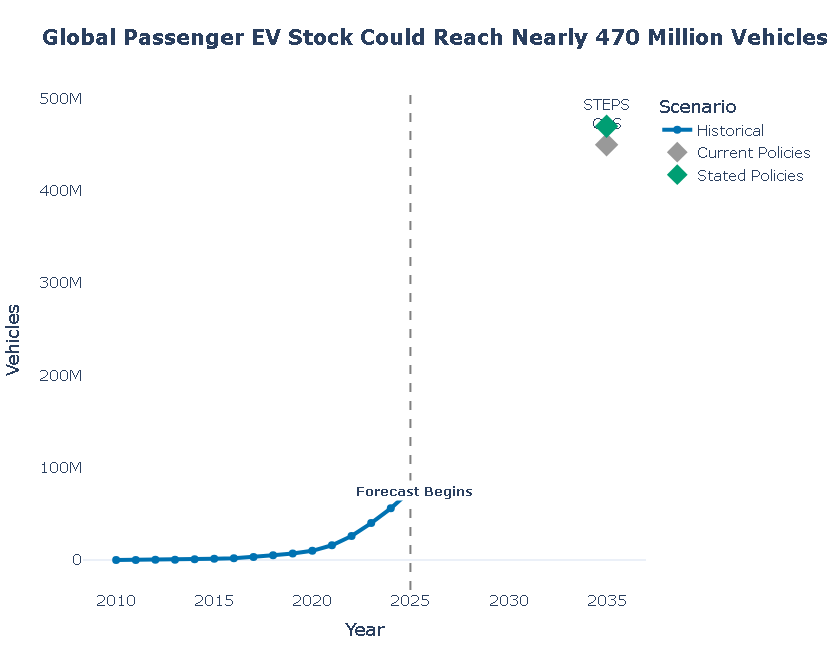

In [17]:
# ==========================================================
# Global EV Stock Outlook
# ==========================================================

import plotly.graph_objects as go

fig = go.Figure()

# Historical trend
fig.add_trace(
    go.Scatter(
        x=historical["year"],
        y=historical["value"],
        mode="lines+markers",
        name="Historical",
        line=dict(color="#0072B2", width=4),
        marker=dict(size=8)
    )
)

# CPS projection
fig.add_trace(
    go.Scatter(
        x=cps["year"],
        y=cps["value"],
        mode="markers+text",
        name="Current Policies",
        marker=dict(
            size=18,
            color="#999999",
            symbol="diamond"
        ),
        text=["CPS"],
        textposition="top center"
    )
)

# STEPS projection
fig.add_trace(
    go.Scatter(
        x=steps["year"],
        y=steps["value"],
        mode="markers+text",
        name="Stated Policies",
        marker=dict(
            size=18,
            color="#009E73",
            symbol="diamond"
        ),
        text=["STEPS"],
        textposition="top center"
    )
)

# Forecast separator
fig.add_vline(
    x=2025,
    line_dash="dash",
    line_color="gray"
)

# Annotation
fig.add_annotation(
    x=2025.2,
    y=historical["value"].max(),
    text="<b>Forecast Begins</b>",
    showarrow=False,
    bgcolor="white",
    font=dict(size=13)
)

fig.update_layout(

    title="<b>Global Passenger EV Stock Could Reach Nearly 470 Million Vehicles by 2035</b>",

    template="plotly_white",

    height=650,

    font=dict(size=15),

    plot_bgcolor="white",

    paper_bgcolor="white",

    xaxis_title="Year",

    yaxis_title="Vehicles",

    legend_title="Scenario",

    margin=dict(l=70, r=40, t=90, b=60)

)

fig.update_xaxes(showgrid=False)

fig.update_yaxes(showgrid=False)

fig.show()

In [18]:
# ==========================================================
# Forecast KPIs
# ==========================================================

historical_2025 = historical.loc[
    historical["year"] == 2025,
    "value"
].iloc[0]

cps_2035 = cps["value"].iloc[0]

steps_2035 = steps["value"].iloc[0]

growth_cps = (cps_2035 - historical_2025) / historical_2025 * 100
growth_steps = (steps_2035 - historical_2025) / historical_2025 * 100

kpi = pd.DataFrame({

    "Metric":[

        "Historical EV Stock (2025)",
        "Projected EV Stock (2035 - CPS)",
        "Projected EV Stock (2035 - STEPS)",
        "Growth (CPS)",
        "Growth (STEPS)"

    ],

    "Value":[

        f"{historical_2025/1e6:.1f} Million",

        f"{cps_2035/1e6:.1f} Million",

        f"{steps_2035/1e6:.1f} Million",

        f"{growth_cps:.1f}%",

        f"{growth_steps:.1f}%"

    ]

})

display(kpi)

,Metric,Value
0,Historical EV Stock (2025),75.0 Million
1,Projected EV Stock (2035 - CPS),450.0 Million
2,Projected EV Stock (2035 - STEPS),470.0 Million
3,Growth (CPS),500.0%
4,Growth (STEPS),526.7%


## Strategic Insight

The historical trend demonstrates sustained acceleration in global passenger EV adoption, culminating in approximately **75 million electric vehicles** worldwide by 2025.

Under the **Current Policies Scenario (CPS)**, the global passenger EV fleet is projected to expand to approximately **450 million vehicles by 2035**, while the **Stated Policies Scenario (STEPS)** projects an even larger market approaching **470 million vehicles**.

Although the difference between the two policy pathways is modest, both scenarios indicate that global electric mobility is expected to remain one of the fastest-growing segments of the transportation sector over the coming decade.

These projections imply substantial future demand for charging infrastructure, battery manufacturing capacity, electricity generation, and critical raw materials, emphasizing the strategic importance of long-term investment planning.

# 4. Policy Scenario Comparison

## Business Question 2

**How much additional electric vehicle adoption could be achieved through stronger policy implementation?**

Future EV adoption depends not only on technological progress but also on government policy and regulatory support.

This section compares the International Energy Agency's two projection scenarios:

- **Current Policies Scenario (CPS)** – continuation of existing policies.
- **Stated Policies Scenario (STEPS)** – implementation of announced policy commitments.

The comparison quantifies the additional market expansion associated with stronger policy action by 2035.

In [19]:
# ==========================================================
# Scenario Comparison Dataset
# ==========================================================

scenario = df[
    (df["parameter"] == "EV stock") &
    (df["mode"] == "Cars") &
    (df["powertrain"] == "EV") &
    (df["Aggregate group"] == "_World") &
    (df["category"].isin(["Projection-CPS", "Projection-STEPS"]))
].copy()

scenario = scenario.sort_values("category")

display(
    scenario[
        [
            "category",
            "year",
            "value"
        ]
    ]
)

,category,year,value
49347,Projection-CPS,2035,"450,000,000.00"
49357,Projection-STEPS,2035,"470,000,000.00"


In [20]:
# ==========================================================
# Scenario KPI Summary
# ==========================================================

scenario_summary = scenario.copy()

scenario_summary["Million Vehicles"] = (
    scenario_summary["value"] / 1_000_000
).round(1)

display(
    scenario_summary[
        [
            "category",
            "Million Vehicles"
        ]
    ]
)

,category,Million Vehicles
49347,Projection-CPS,450.00
49357,Projection-STEPS,470.00


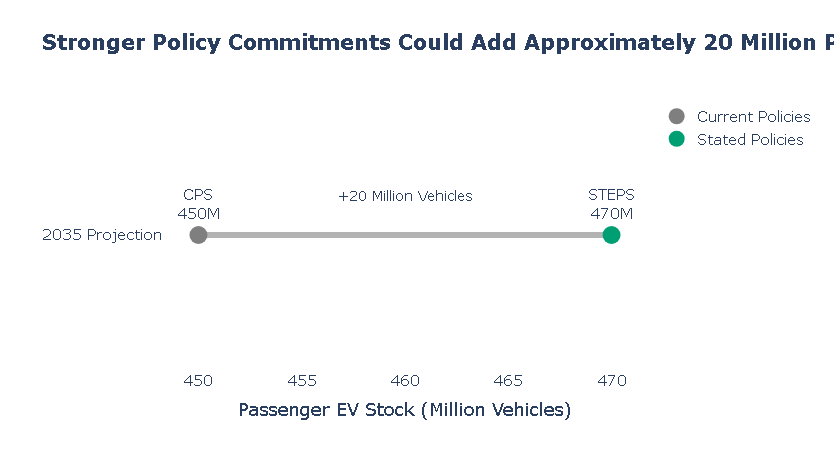

In [21]:
import plotly.graph_objects as go

cps_value = scenario.loc[
    scenario["category"] == "Projection-CPS",
    "value"
].iloc[0] / 1_000_000

steps_value = scenario.loc[
    scenario["category"] == "Projection-STEPS",
    "value"
].iloc[0] / 1_000_000

gap = steps_value - cps_value

fig = go.Figure()

# Connecting line
fig.add_trace(
    go.Scatter(
        x=[cps_value, steps_value],
        y=["2035 Projection", "2035 Projection"],
        mode="lines",
        line=dict(color="#B3B3B3", width=6),
        showlegend=False
    )
)

# CPS
fig.add_trace(
    go.Scatter(
        x=[cps_value],
        y=["2035 Projection"],
        mode="markers+text",
        marker=dict(
            size=18,
            color="#7F7F7F"
        ),
        text=[f"CPS<br>{cps_value:.0f}M"],
        textposition="top center",
        name="Current Policies"
    )
)

# STEPS
fig.add_trace(
    go.Scatter(
        x=[steps_value],
        y=["2035 Projection"],
        mode="markers+text",
        marker=dict(
            size=18,
            color="#009E73"
        ),
        text=[f"STEPS<br>{steps_value:.0f}M"],
        textposition="top center",
        name="Stated Policies"
    )
)

fig.add_annotation(
    x=(cps_value + steps_value) / 2,
    y="2035 Projection",
    text=f"+{gap:.0f} Million Vehicles",
    showarrow=False,
    yshift=40,
    font=dict(size=14)
)

fig.update_layout(

    title="<b>Stronger Policy Commitments Could Add Approximately 20 Million Passenger EVs by 2035</b>",

    template="plotly_white",

    height=450,

    xaxis_title="Passenger EV Stock (Million Vehicles)",

    yaxis_title="",

    plot_bgcolor="white",

    paper_bgcolor="white",

    font=dict(size=15)

)

fig.update_xaxes(showgrid=False)

fig.update_yaxes(showgrid=False)

fig.show()

## Strategic Insight

Both policy scenarios indicate substantial long-term expansion of the global passenger EV fleet.

Under the **Current Policies Scenario (CPS)**, global passenger EV stock is projected to reach approximately **450 million vehicles** by 2035.

Under the **Stated Policies Scenario (STEPS)**, passenger EV stock increases further to approximately **470 million vehicles**, representing an additional **20 million vehicles** compared with the current policy pathway.

Although both scenarios predict continued market expansion, the comparison illustrates that stronger policy implementation can accelerate EV adoption and increase long-term market penetration.

The results emphasize the importance of supportive government policies, charging infrastructure investment, and coordinated regulatory frameworks in achieving faster electrification.

# 5. Future Global Market Leaders

## Business Question 3

**Which countries are projected to lead the global passenger EV market by 2035?**

Although global EV adoption is expected to accelerate, future market growth will not be distributed equally across all countries.

Identifying the largest projected markets helps governments, manufacturers, investors, and infrastructure providers understand where future demand is expected to be concentrated.

This analysis ranks countries according to their projected passenger EV stock under the **Stated Policies Scenario (STEPS)**.

In [22]:
# ==========================================================
# Top Projected EV Markets (2035)
# ==========================================================

top_markets = (
    df[
        (df["category"] == "Projection-STEPS") &
        (df["parameter"] == "EV stock") &
        (df["mode"] == "Cars") &
        (df["powertrain"] == "EV") &
        (df["Aggregate group"] == "Projection_country")
    ]
    .groupby("region_country", as_index=False)["value"]
    .sum()
    .sort_values("value", ascending=False)
    .head(15)
)

top_markets["Million Vehicles"] = (
    top_markets["value"] / 1_000_000
).round(1)

display(top_markets)

,region_country,value,Million Vehicles
0,China,"260,000,000.00",260.00
4,USA,"27,000,000.00",27.00
1,India,"11,000,000.00",11.00
3,Korea,"8,600,000.00",8.60
2,Japan,"4,800,000.00",4.80


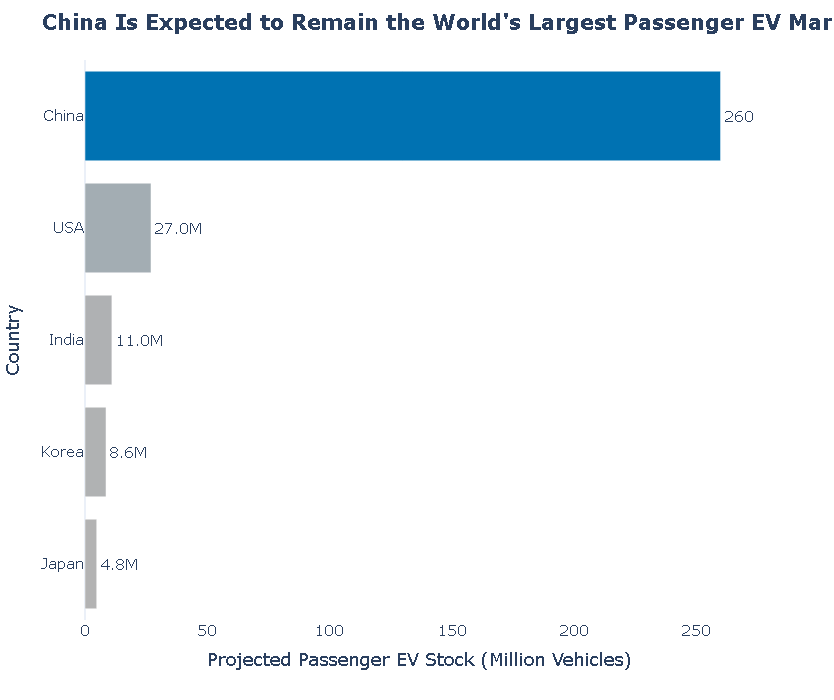

In [23]:
import plotly.express as px

fig = px.bar(

    top_markets.sort_values("Million Vehicles"),

    x="Million Vehicles",

    y="region_country",

    orientation="h",

    text="Million Vehicles",

    color="Million Vehicles",

    color_continuous_scale=[
        "#B3B3B3",
        "#0072B2"
    ]

)

fig.update_traces(

    texttemplate="%{text:.1f}M",

    textposition="outside"

)

fig.update_layout(

    title="<b>China Is Expected to Remain the World's Largest Passenger EV Market by 2035</b>",

    template="plotly_white",

    height=700,

    coloraxis_showscale=False,

    xaxis_title="Projected Passenger EV Stock (Million Vehicles)",

    yaxis_title="Country",

    font=dict(size=15),

    plot_bgcolor="white",

    paper_bgcolor="white"

)

fig.update_xaxes(showgrid=False)

fig.update_yaxes(showgrid=False)

fig.show()

## Strategic Insight

The projection highlights a clear concentration of future passenger EV adoption within a relatively small number of countries.

The leading markets are expected to account for a substantial proportion of global EV deployment, reflecting differences in market maturity, policy support, manufacturing capacity, and consumer adoption.

Countries with larger projected EV fleets are also expected to require significant expansion of charging infrastructure, electricity generation, battery supply chains, and supporting transportation policies.

These markets are therefore likely to represent the highest-priority locations for future investment across the global EV ecosystem.

# 6. Future Charging Infrastructure Requirements

## Business Question 4

**Where will charging infrastructure need to expand the most by 2035?**

The rapid growth of electric vehicles will require significant expansion of charging infrastructure.

Comparing projected EV stock with projected charging points provides insight into whether infrastructure development is likely to keep pace with vehicle adoption.

Countries exhibiting both high EV stock and high infrastructure demand represent strategic investment opportunities for governments, utilities, charging operators, and private investors.

In [24]:
# ==========================================================
# EV Stock vs Charging Infrastructure (2035)
# ==========================================================

stock_2035 = df[
    (df["category"] == "Projection-STEPS") &
    (df["parameter"] == "EV stock") &
    (df["mode"] == "Cars") &
    (df["powertrain"] == "EV") &
    (df["Aggregate group"] == "Projection_country")
][["region_country", "value"]].rename(
    columns={"value": "EV_Stock"}
)

charging_2035 = df[
    (df["category"] == "Projection-STEPS") &
    (df["parameter"] == "EV charging points") &
    (df["Aggregate group"] == "Projection_country")
][["region_country", "value"]].rename(
    columns={"value": "Charging_Points"}
)

infrastructure = stock_2035.merge(
    charging_2035,
    on="region_country",
    how="inner"
)

infrastructure["EVs_per_Charging_Point"] = (
    infrastructure["EV_Stock"] /
    infrastructure["Charging_Points"]
)

display(infrastructure.head())

,region_country,EV_Stock,Charging_Points,EVs_per_Charging_Point
0,China,"260,000,000.00","5,400,000.00",48.15
1,China,"260,000,000.00","9,000,000.00",28.89
2,China,"260,000,000.00","3,700,000.00",70.27
3,India,"11,000,000.00","370,000.00",29.73
4,India,"11,000,000.00","690,000.00",15.94


In [25]:
print("=" * 70)
print("INFRASTRUCTURE DATASET")
print("=" * 70)

print(f"Countries : {len(infrastructure)}")

display(
    infrastructure.describe().round(2)
)

INFRASTRUCTURE DATASET
Countries : 15


,EV_Stock,Charging_Points,EVs_per_Charging_Point
count,15.00,15.00,15.00
mean,"62,280,000.00","1,397,733.33",123.36
std,"102,629,369.23","2,619,215.63",115.66
min,"4,800,000.00","13,000.00",10.62
25%,"8,600,000.00","76,500.00",38.94
50%,"11,000,000.00","120,000.00",78.69
75%,"27,000,000.00","750,000.00",175.74
max,"260,000,000.00","9,000,000.00",369.23


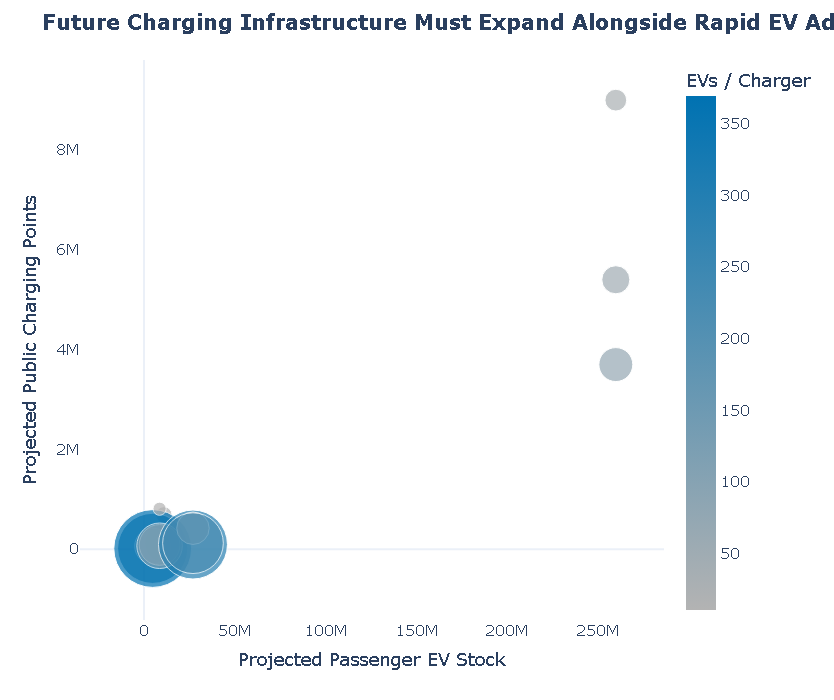

In [26]:
import plotly.express as px

fig = px.scatter(

    infrastructure,

    x="EV_Stock",

    y="Charging_Points",

    size="EVs_per_Charging_Point",

    hover_name="region_country",

    color="EVs_per_Charging_Point",

    color_continuous_scale=[
        "#B3B3B3",
        "#0072B2"
    ],

    size_max=55

)

fig.update_layout(

    title="<b>Future Charging Infrastructure Must Expand Alongside Rapid EV Adoption</b>",

    template="plotly_white",

    height=700,

    xaxis_title="Projected Passenger EV Stock",

    yaxis_title="Projected Public Charging Points",

    coloraxis_colorbar_title="EVs / Charger",

    plot_bgcolor="white",

    paper_bgcolor="white",

    font=dict(size=15)

)

fig.update_xaxes(showgrid=False)

fig.update_yaxes(showgrid=False)

fig.show()

## Strategic Insight

The relationship between projected EV stock and charging infrastructure highlights substantial variation across countries.

Markets with large projected EV fleets require proportional expansion of public charging infrastructure to maintain accessibility and user convenience.

Countries exhibiting a high number of electric vehicles per charging point may experience increased infrastructure pressure, indicating potential investment opportunities for charging network operators and public-sector infrastructure programs.

These findings demonstrate that vehicle adoption and infrastructure deployment must progress simultaneously to sustain long-term market growth.

# 7. Future Electricity Demand

## Business Question 5

**How will electricity demand evolve as electric vehicle adoption accelerates?**

Large-scale electrification of transport will substantially increase electricity consumption.

Understanding future electricity demand is essential for utilities, grid operators, energy planners, and governments responsible for maintaining reliable electricity systems.

This analysis compares historical demand with official policy projections to evaluate the future impact of EV adoption on electricity consumption.

In [27]:
# ==========================================================
# Global Electricity Demand
# ==========================================================

electricity = df[
    (df["parameter"] == "Electricity demand") &
    (df["Aggregate group"] == "_World")
].copy()

electricity = electricity.sort_values(
    ["category", "year"]
)

display(
    electricity[
        [
            "category",
            "year",
            "value"
        ]
    ]
)

,category,year,value
6879,Historical,2010,12.00
6895,Historical,2010,430.00
6911,Historical,2010,230.00
6927,Historical,2010,"1,000.00"
6943,Historical,2010,76.00
6880,Historical,2011,15.00
6896,Historical,2011,340.00
6912,Historical,2011,"1,400.00"
6928,Historical,2011,170.00
6944,Historical,2011,74.00


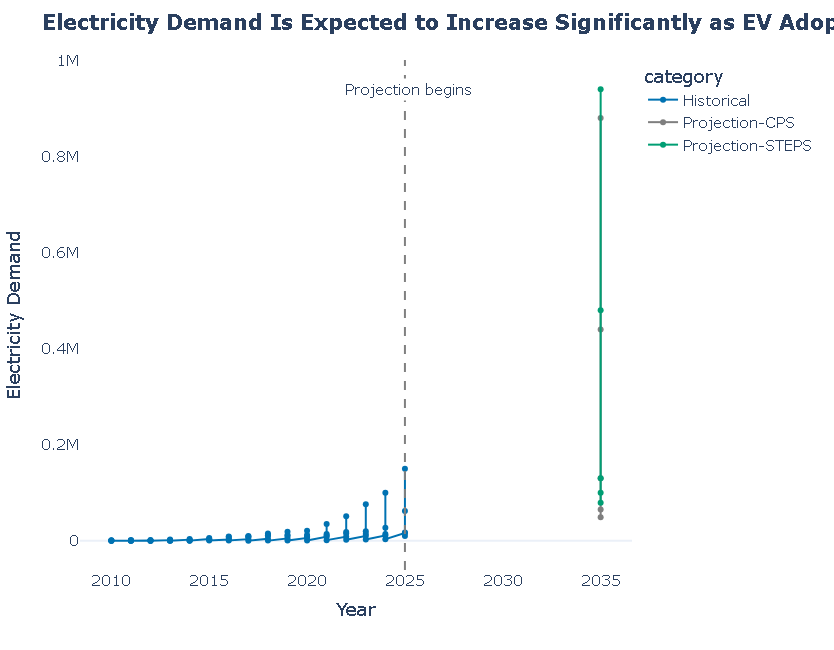

In [28]:
import plotly.express as px

fig = px.line(

    electricity,

    x="year",

    y="value",

    color="category",

    markers=True,

    color_discrete_map={

        "Historical":"#0072B2",

        "Projection-CPS":"#7F7F7F",

        "Projection-STEPS":"#009E73"

    }

)

fig.add_vline(
    x=2025,
    line_dash="dash",
    line_color="gray"
)

fig.add_annotation(
    x=2025.2,
    y=electricity["value"].max(),
    text="Projection begins",
    showarrow=False,
    bgcolor="white"
)

fig.update_layout(

    title="<b>Electricity Demand Is Expected to Increase Significantly as EV Adoption Expands</b>",

    template="plotly_white",

    height=650,

    xaxis_title="Year",

    yaxis_title="Electricity Demand",

    plot_bgcolor="white",

    paper_bgcolor="white",

    font=dict(size=15)

)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

### Strategic Insight

Future EV adoption is expected to substantially increase electricity demand.

This highlights the importance of expanding renewable energy generation, strengthening electricity transmission networks, and investing in smart charging technologies.

Without corresponding improvements in energy infrastructure, rapid EV adoption could increase pressure on national electricity systems.

These findings reinforce the need for coordinated planning across transportation and energy sectors.

# 8. Energy Transition Outlook

## Business Question 6

**How will increasing EV adoption reshape the broader energy system?**

Electric vehicles influence much more than transportation.

As adoption accelerates, demand for battery manufacturing, electricity generation, and renewable energy integration is expected to increase, while dependence on petroleum products is expected to decline.

This section examines how projected EV growth aligns with battery deployment and oil displacement, illustrating the broader transformation of the global energy system.

In [29]:
# ==========================================================
# Energy Transition Indicators
# ==========================================================

transition = df[

    (df["Aggregate group"] == "_World") &

    (

        df["parameter"].isin([

            "Battery deployment",

            "Oil displacement, Mbd",

            "Electricity demand"

        ])

    )

].copy()

transition = transition.sort_values(

    ["parameter","category","year"]

)

display(

    transition[
        [

            "parameter",

            "category",

            "year",

            "value"

        ]

    ]

)

,parameter,category,year,value
43369,Battery deployment,Historical,2015,1.10
43467,Battery deployment,Historical,2015,10.00
43566,Battery deployment,Historical,2015,13.00
43643,Battery deployment,Historical,2015,2.10
43731,Battery deployment,Historical,2015,0.34
...,...,...,...,...
7208,"Oil displacement, Mbd",Projection-STEPS,2035,0.56
7209,"Oil displacement, Mbd",Projection-STEPS,2035,0.45
7210,"Oil displacement, Mbd",Projection-STEPS,2035,7.10
7211,"Oil displacement, Mbd",Projection-STEPS,2035,1.00


In [30]:
# ==========================================================
# Normalized Transition Indicators
# ==========================================================

transition_plot = transition.copy()

transition_plot["Normalized"] = (

    transition_plot

    .groupby("parameter")["value"]

    .transform(lambda x: x / x.max())

)

display(transition_plot.head())

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group,Normalized
43369,World,Historical,Battery deployment,2 and 3 wheelers,EV,2015,GWh,1.10,_World,0.00
43467,World,Historical,Battery deployment,Buses,EV,2015,GWh,10.00,_World,0.00
43566,World,Historical,Battery deployment,Cars,EV,2015,GWh,13.00,_World,0.00
43643,World,Historical,Battery deployment,Trucks,EV,2015,GWh,2.10,_World,0.00
43731,World,Historical,Battery deployment,Vans,EV,2015,GWh,0.34,_World,0.00


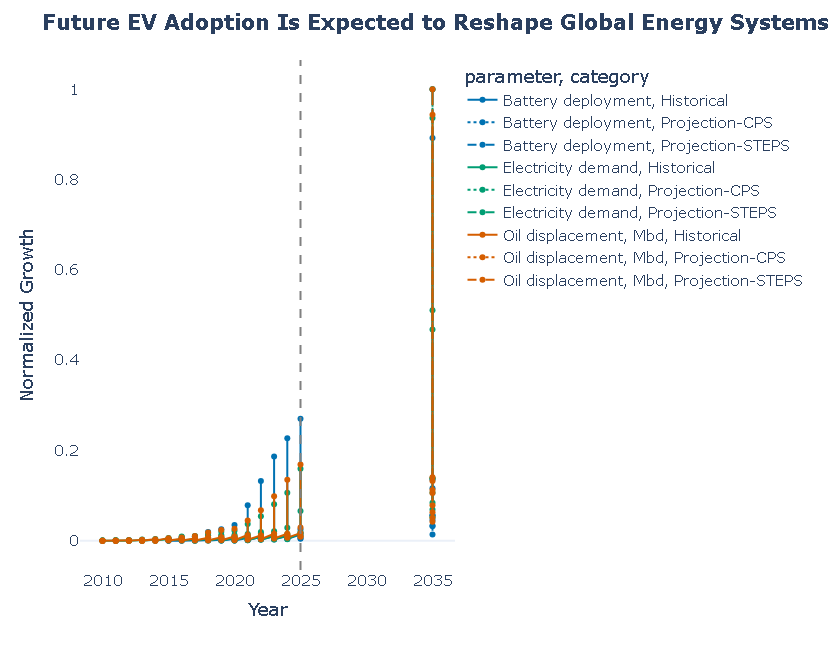

In [31]:
import plotly.express as px

fig = px.line(

    transition_plot,

    x="year",

    y="Normalized",

    color="parameter",

    line_dash="category",

    markers=True,

    color_discrete_sequence=[

        "#0072B2",

        "#009E73",

        "#D55E00"

    ]

)

fig.add_vline(

    x=2025,

    line_dash="dash",

    line_color="gray"

)

fig.update_layout(

    title="<b>Future EV Adoption Is Expected to Reshape Global Energy Systems</b>",

    template="plotly_white",

    height=650,

    xaxis_title="Year",

    yaxis_title="Normalized Growth",

    plot_bgcolor="white",

    paper_bgcolor="white",

    font=dict(size=15)

)

fig.update_xaxes(showgrid=False)

fig.update_yaxes(showgrid=False)

fig.show()

### Strategic Insight

The projections indicate that the transition toward electric mobility extends well beyond vehicle adoption.

Future EV growth is expected to increase electricity demand and battery deployment while simultaneously reducing dependence on petroleum through greater oil displacement.

These trends highlight the interconnected nature of transport, energy infrastructure, and industrial supply chains, reinforcing the need for coordinated long-term planning across multiple sectors.

# 9. Executive Forecast Dashboard

The following dashboard summarizes the principal findings from the forecasting analyses and provides a concise overview of the expected evolution of the global electric vehicle market.

In [32]:
forecast_dashboard = pd.DataFrame({

    "Forecast KPI":[

        "Historical EV Stock (2025)",

        "Projected EV Stock (2035 - CPS)",

        "Projected EV Stock (2035 - STEPS)",

        "Countries Included",

        "Projection Horizon"

    ],

    "Value":[

        "75 Million",

        "450 Million",

        "470 Million",

        df["region_country"].nunique(),

        "2025–2035"

    ]

})

display(
    forecast_dashboard.style.hide(axis="index")
)

Forecast KPI,Value
Historical EV Stock (2025),75 Million
Projected EV Stock (2035 - CPS),450 Million
Projected EV Stock (2035 - STEPS),470 Million
Countries Included,72
Projection Horizon,2025–2035


# 10. Strategic Recommendations

### Governments

- Continue strengthening long-term EV policy frameworks.
- Accelerate public charging infrastructure deployment.
- Invest in electricity grid modernization.

### Vehicle Manufacturers

- Expand production capacity for affordable passenger EVs.
- Improve battery efficiency and vehicle affordability.

### Energy Utilities

- Prepare electricity systems for sustained growth in EV demand.
- Increase renewable energy integration with transport electrification.

### Investors

- Prioritize markets exhibiting high projected EV growth and infrastructure demand.
- Focus investment on charging networks, battery technologies, and supporting supply chains.

# 11. Final Conclusion

This notebook extended the exploratory analyses by examining the future outlook of the global electric vehicle market using official International Energy Agency projection scenarios.

The results indicate that electric mobility is expected to continue expanding rapidly under both policy scenarios, with global passenger EV stock projected to approach **450–470 million vehicles by 2035**.

Future market growth will require significant investment in charging infrastructure, electricity generation, battery manufacturing, and supporting transport policies.

Together with the findings from the previous notebooks, these results demonstrate that the global transition toward electric mobility represents a long-term structural transformation rather than a short-term technological trend.

The insights generated throughout this project provide an evidence-based foundation for strategic planning by governments, manufacturers, investors, and infrastructure providers.